# Big Data in Finance: Part IV <BR><BR> Lecture Notes 4: Merge CRSP and Compustat 
    
**Instructor** <BR>
Kirsten Burr, kburr26@gsb.columbia.edu
    
**TA's:** <BR>
Luman Zou, lz2867@columbia.edu <BR>
Yifan Wan, YWan26@gsb.columbia.edu

<sub> Credit: lecture notes adapted from notes developed by Lira Mota

## Objective:
    
Create a final data set called "stock_annual" that has both crsp (permno/permco) and compustat (gvkey) identifiers.

## Set Up

In [1]:
#%% Packages 
import wrds
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import time
from time import strptime, strftime

# Setups
pd.set_option("display.max_rows", 500) # max number or rows to be displayed 
%matplotlib inline 
plt.rcParams['figure.figsize'] = [10, 6]

In [2]:
db = wrds.Connection(wrds_username='khardnett')  # make sure to configure wrds connector before hand.

Loading library list...
Done


In [3]:
# Load Compustat and CRSP data. Data downloaded in lecture notes 2 and 3.
compa = pd.read_pickle('compa_annual.pkl')
crspm = pd.read_pickle('crsp_monthly.pkl')

## What is the difficulty with merging CRSP and Compustat?

In [4]:
print(crspm.columns)
print(compa.columns)

Index(['mthcaldt', 'permno', 'mthprc', 'mthprcflg', 'mthprcdt', 'mthdtflg',
       'mthret', 'mthretx', 'mthdelflg', 'mthvol', 'mthshrout', 'mthcumfacpr',
       'mthcumfacshr', 'secinfostartdt', 'secinfoenddt', 'securitybegdt',
       'securityenddt', 'permco', 'cusip', 'hdrcusip', 'ticker', 'securitynm',
       'issuernm', 'primaryexch', 'conditionaltype', 'tradingstatusflg',
       'shareclass', 'sharetype', 'securitytype', 'securitysubtype',
       'usincflg', 'issuertype', 'siccd', 'naics', 'me', 'mesum', 'prc_adj',
       'shrout_adj', 'vol_adj', 'melag_nt', 'melag', 'rankyear', 'mdate',
       'rf'],
      dtype='object')
Index(['gvkey', 'datadate', 'conm', 'tic', 'cusip', 'fyear', 'fyr', 'at',
       'capx', 'ceq', 'cogs', 'csho', 'dlc', 'dlcch', 'dltt', 'dp', 'ib',
       'itcb', 'lt', 'mib', 'naicsh', 'ni', 'prstkcc', 'pstk', 'pstkl',
       'pstkrv', 're', 'revt', 'sale', 'seq', 'sich', 'txdb', 'txdi', 'txditc',
       'wcapch', 'xint', 'xlr', 'xrd', 'xsga', 'se', 'ps', 'dt'

### Possibility: CUSIP

A CUSIP is a nine-digit numeric (e.g. 037833100 for Apple) or nine-character alphanumeric (e.g. 38259P508 for Google) code that identifies a North American financial security for the purposes of facilitating clearing and settlement of trades. The CUSIP was adopted as an American National Standard under Accredited Standards X9.6. The acronym, pronounced as "kyoo-sip," derives from Committee on Uniform Security Identification Procedures.

The CUSIP system is owned by the American Bankers Association and is operated by S&P Global Market Intelligence. The operating body, CUSIP Global Services (CGS), also serves as the national numbering agency (NNA) for North America, and the CUSIP serves as the National Securities Identification Number (NSIN) for products issued from both the United States and Canada. 

Source: Wikipedia 


In [5]:
crspm[['permno', 'mthcaldt', 'issuernm', 'ticker', 'cusip', 'hdrcusip']][(crspm.permno==90319)&(crspm.mthcaldt.dt.year==2015)]

,permno,mthcaldt,issuernm,ticker,cusip,hdrcusip
3734717,90319,2015-01-30,GOOGLE INC,GOOGL,38259P50,02079K30
3734718,90319,2015-02-27,GOOGLE INC,GOOGL,38259P50,02079K30
3734719,90319,2015-03-31,GOOGLE INC,GOOGL,38259P50,02079K30
3734720,90319,2015-04-30,GOOGLE INC,GOOGL,38259P50,02079K30
3734721,90319,2015-05-29,GOOGLE INC,GOOGL,38259P50,02079K30
3734722,90319,2015-06-30,GOOGLE INC,GOOGL,38259P50,02079K30
3734723,90319,2015-07-31,GOOGLE INC,GOOGL,38259P50,02079K30
3734724,90319,2015-08-31,GOOGLE INC,GOOGL,38259P50,02079K30
3734725,90319,2015-09-30,GOOGLE INC,GOOGL,38259P50,02079K30
3734726,90319,2015-10-30,ALPHABET INC,GOOGL,02079K30,02079K30


In [6]:
compa[['gvkey', 'datadate', 'conm', 'tic', 'cusip']][(compa.tic=='GOOGL')]

,gvkey,datadate,conm,tic,cusip
428054,160329,2002-12-31,ALPHABET INC,GOOGL,02079K305
428055,160329,2003-12-31,ALPHABET INC,GOOGL,02079K305
428056,160329,2004-12-31,ALPHABET INC,GOOGL,02079K305
428057,160329,2005-12-31,ALPHABET INC,GOOGL,02079K305
428058,160329,2006-12-31,ALPHABET INC,GOOGL,02079K305
428059,160329,2007-12-31,ALPHABET INC,GOOGL,02079K305
428060,160329,2008-12-31,ALPHABET INC,GOOGL,02079K305
428061,160329,2009-12-31,ALPHABET INC,GOOGL,02079K305
428063,160329,2010-12-31,ALPHABET INC,GOOGL,02079K305
428064,160329,2011-12-31,ALPHABET INC,GOOGL,02079K305


### Possibility: Names or Ticker 

In [7]:
crspm_t = crspm[['permno','permco','mthcaldt', 'issuernm', 'ticker', 
                 'cusip', 'hdrcusip', 'mthprc', 'mthret']][crspm.ticker=='T']

In [8]:
crspm_t[crspm_t.issuernm=='AMERICAN TELEPHONE & TELEG CO'].sort_values('mthcaldt').tail()

,permno,permco,mthcaldt,issuernm,ticker,cusip,hdrcusip,mthprc,mthret
52830,10401,20103,1993-11-30,AMERICAN TELEPHONE & TELEG CO,T,03017710,00195750,54.625,-0.050000
52831,10401,20103,1993-12-31,AMERICAN TELEPHONE & TELEG CO,T,03017710,00195750,52.500,-0.033082
52832,10401,20103,1994-01-31,AMERICAN TELEPHONE & TELEG CO,T,03017710,00195750,56.750,0.080952
52833,10401,20103,1994-02-28,AMERICAN TELEPHONE & TELEG CO,T,03017710,00195750,52.500,-0.074890
52834,10401,20103,1994-03-31,AMERICAN TELEPHONE & TELEG CO,T,03017710,00195750,51.250,-0.017688


In [9]:
crspm_t[crspm_t.issuernm=='A T & T CORP'].sort_values('mthcaldt').head()

,permno,permco,mthcaldt,issuernm,ticker,cusip,hdrcusip,mthprc,mthret
52835,10401,20103,1994-04-29,A T & T CORP,T,00195710,00195750,51.250,0.000000
52836,10401,20103,1994-05-31,A T & T CORP,T,00195710,00195750,54.625,0.065854
52837,10401,20103,1994-06-30,A T & T CORP,T,00195710,00195750,54.375,0.001535
52838,10401,20103,1994-07-29,A T & T CORP,T,00195710,00195750,54.625,0.004598
52839,10401,20103,1994-08-31,A T & T CORP,T,00195710,00195750,54.625,0.000000


[AT&T accquired by SBC](https://urldefense.proofpoint.com/v2/url?u=https-3A__investors.att.com_stockholder-2Dservices_cost-2Dbasis-2Dguide_worksheet_att-2Dcorp&d=DwMFAg&c=009klHSCxuh5AI1vNQzSO0KGjl4nbi2Q0M1QLJX9BeE&r=m3cgfvM0663JvpScJDvmDKbkzvoES7vfUoxkLJ1CA8Q&m=fz9D49wz2fY6QL72Wjv8RSevSyldgUBD4fISth0ehKBmmWCtm4EDaF7IW8gfnVML&s=Y03fuTsnnVYL7BQGwTVXf9UqnjXdvCC2q2Bn2PPtSRM&e=)

In [10]:
crspm_t[crspm_t.issuernm=='A T & T INC'].sort_values('mthcaldt')

,permno,permco,mthcaldt,issuernm,ticker,cusip,hdrcusip,mthprc,mthret
1967245,66093,21645,2005-12-30,A T & T INC,T,00206R10,00206R10,24.49,-0.016861
1967246,66093,21645,2006-01-31,A T & T INC,T,00206R10,00206R10,25.95,0.073749
1967247,66093,21645,2006-02-28,A T & T INC,T,00206R10,00206R10,27.59,0.063199
1967248,66093,21645,2006-03-31,A T & T INC,T,00206R10,00206R10,27.04,-0.019935
1967249,66093,21645,2006-04-28,A T & T INC,T,00206R10,00206R10,26.21,-0.018510
1967250,66093,21645,2006-05-31,A T & T INC,T,00206R10,00206R10,26.06,-0.005723
1967251,66093,21645,2006-06-30,A T & T INC,T,00206R10,00206R10,27.89,0.070223
1967252,66093,21645,2006-07-31,A T & T INC,T,00206R10,00206R10,29.99,0.088222
1967253,66093,21645,2006-08-31,A T & T INC,T,00206R10,00206R10,31.13,0.038013
1967254,66093,21645,2006-09-29,A T & T INC,T,00206R10,00206R10,32.56,0.045936


## Query CRSP/Compustat merged table (annual or quarterly).

1. Output table is CRSP-centric with permno-datadate being the primary key.
2. Fiscal period end date must be within link date range.
3. WRDS SAS code can be found [here](https://wrds-www.wharton.upenn.edu/pages/wrds-research/applications/linking-databases/linking-crsp-and-compustat/).

## Many Linking Tables

In [11]:
crsp_tables = db.list_tables(library="crsp") 
crsp_tables = pd.DataFrame({'tables':crsp_tables}) # Transform libs to a Pandas data frame to have a better display.
crsp_tables[crsp_tables.tables.str.contains('ccm')]

,tables
19,ccm_lookup
20,ccm_qvards
21,ccmxpf_linktable
22,ccmxpf_lnkhist
23,ccmxpf_lnkrng
24,ccmxpf_lnkused


**CCMXPF_LNKHIST - Link History**


* CCMXPF_LNKHIST contains the historical and current links between GVKEY and LPERMNO/LPERMCO (previously known as NPERMN O/NPERMCO in old version CCM). 


* In addition, it includes the beginning and ending dates for links, the link types, and the primary issue marker, and liid codes (Compustat's secondary ID variable, IID).

[Source](https://wrds-www.wharton.upenn.edu/data-dictionary/crsp_q_ccm/ccmxpf_lnkhist/)

## Many Linking Types

In [12]:
db.describe_table(library="crsp", table="ccmxpf_lnkhist")

Approximately 120083 rows in crsp.ccmxpf_lnkhist.


,name,nullable,type,comment
0,gvkey,True,VARCHAR(6),Standard and Poor's Identifier
1,linkprim,True,VARCHAR(1),Primary Link Marker
2,liid,True,VARCHAR(3),Security-level Identifier
3,linktype,True,VARCHAR(2),Link Type Codd
4,lpermno,True,DOUBLE PRECISION,Historical CRSP PERMNO Link to COMPUSTAT Record
5,lpermco,True,DOUBLE PRECISION,Historical CRSP PERMCO Link to COMPUSTAT Record
6,linkdt,True,DATE,First Effective Date of Link
7,linkenddt,True,DATE,Last Effective Date of Link


## Download Data

In [13]:
sql = '''SELECT gvkey, lpermno as permno, lpermco as permco, linktype, linkdt, linkenddt
         FROM crsp.ccmxpf_lnkhist
         WHERE linktype IN ('LC', 'LU', 'LS') 
      ''' 

link_table = db.raw_sql(sql, date_cols=['linkdt', 'linkenddt'])

## Understading Linking Table

In [14]:
# Example 
link_table[link_table.permco==21645]

,gvkey,permno,permco,linktype,linkdt,linkenddt
9031,009899,66093.0,21645.0,LC,1984-02-16,NaT


In [15]:
# Example: LIBERTY MEDIA
link_table[link_table.permco==54311]

,gvkey,permno,permco,linktype,linkdt,linkenddt
14790,017010,13757.0,54311.0,LC,2013-01-14,2016-04-17
14791,017010,13758.0,54311.0,LC,2013-01-14,2016-04-17
14792,017010,14811.0,54311.0,LC,2014-07-24,2016-04-17
14793,017010,15998.0,54311.0,LC,2016-04-18,2017-12-31
14794,017010,15998.0,54311.0,LC,2018-01-01,2024-09-10
14795,017010,15999.0,54311.0,LC,2016-04-18,2024-09-10
14796,017010,16000.0,54311.0,LC,2016-04-18,2017-12-31
14797,017010,16000.0,54311.0,LC,2018-01-01,2024-09-10
19401,027186,15996.0,54311.0,LC,2016-04-18,2017-12-31
19402,027186,15996.0,54311.0,LC,2018-01-01,2023-07-18


## Merge and Link

* Link type code. Each link is given a code describing the connection between the CRSP and Compustat data. 

* Values are:

    * LC – Link research complete. Standard connection between databases.
    * LU – Unresearched link to issue by CUSIP
    * LS – Link valid for this security only. Other CRSP PERMNOs with the same PERMCO will link to other GVKEYs.
    * LX – Link to a security that trades on another exchange system not included in CRSP data.
    * LD – Duplicate Link to a security. Another GVKEY/IID is a better link to that CRSP record.
    * LN – Primary link exists but Compustat does not have prices.
    * NR – No link available, confirmed by research
    * NU – No link available, not yet confirmed

In [16]:
link_table.linktype.value_counts()

linktype
LC    17932
LU    15945
LS     7159
Name: count, dtype: int64

In [17]:
compa.head()

,gvkey,datadate,conm,tic,cusip,fyear,fyr,at,capx,ceq,...,ps,dt,be,cost,op,opbe,at_lag,inv,fdiff,inv_capx
0,001001,1980-12-31,A & M FOOD SERVICES INC,AMFD.,000165100,1980,12,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,001001,1981-12-31,A & M FOOD SERVICES INC,AMFD.,000165100,1981,12,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
2,001001,1982-12-31,A & M FOOD SERVICES INC,AMFD.,000165100,1982,12,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,001001,1983-12-31,A & M FOOD SERVICES INC,AMFD.,000165100,1983,12,14.080,3.367,7.823,...,0.0,0.000,7.823,23.508,1.887,0.241212,NaN,NaN,1.0,NaN
5,001001,1984-12-31,A & M FOOD SERVICES INC,AMFD.,000165100,1984,12,16.267,5.496,8.962,...,0.0,0.357,9.319,29.460,2.547,0.273313,14.08,0.155327,1.0,0.390341


In [18]:
df = pd.merge(compa, link_table, on=['gvkey'], how='inner') 
df

,gvkey,datadate,conm,tic,cusip,fyear,fyr,at,capx,ceq,...,opbe,at_lag,inv,fdiff,inv_capx,permno,permco,linktype,linkdt,linkenddt
0,001001,1980-12-31,A & M FOOD SERVICES INC,AMFD.,000165100,1980,12,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,10015.0,6398.0,LU,1983-09-20,1986-07-31
1,001001,1981-12-31,A & M FOOD SERVICES INC,AMFD.,000165100,1981,12,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,NaN,10015.0,6398.0,LU,1983-09-20,1986-07-31
2,001001,1982-12-31,A & M FOOD SERVICES INC,AMFD.,000165100,1982,12,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,NaN,10015.0,6398.0,LU,1983-09-20,1986-07-31
3,001001,1983-12-31,A & M FOOD SERVICES INC,AMFD.,000165100,1983,12,14.080,3.367,7.823,...,0.241212,NaN,NaN,1.0,NaN,10015.0,6398.0,LU,1983-09-20,1986-07-31
4,001001,1984-12-31,A & M FOOD SERVICES INC,AMFD.,000165100,1984,12,16.267,5.496,8.962,...,0.273313,14.080,0.155327,1.0,0.390341,10015.0,6398.0,LU,1983-09-20,1986-07-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488948,366911,2024-12-31,AMRIZE LTD,AMRZ,H2927K103,2024,12,23805.000,642.000,9915.000,...,0.258598,23047.000,0.032889,1.0,0.027856,26806.0,60348.0,LC,2025-06-23,NaT
488949,366911,2025-12-31,AMRIZE LTD,AMRZ,H2927K103,2025,12,24249.000,788.000,13254.000,...,0.193149,23805.000,0.018652,1.0,0.033102,26806.0,60348.0,LC,2025-06-23,NaT
488950,369350,2023-12-31,THE MAGNUM ICE CREAM CO,MICC,N5505D105,2023,12,5828.486,307.286,2774.417,...,0.449801,NaN,NaN,NaN,NaN,27874.0,60606.0,LC,2025-12-08,NaT
488951,369350,2024-12-31,THE MAGNUM ICE CREAM CO,MICC,N5505D105,2024,12,5715.961,332.336,2876.098,...,0.449964,5828.486,-0.019306,1.0,0.057019,27874.0,60606.0,LC,2025-12-08,NaT


In [19]:
# Keep only link in the right range
df = df[(df.datadate >= df.linkdt) | (df.linkdt.isnull())]
df = df[(df.datadate <= df.linkenddt) | (df.linkenddt.isnull())]

In [20]:
df['permno'] = df['permno'].astype(int)
df['permco'] = df['permco'].astype(int)
df['datadate'] = pd.to_datetime(df['datadate'])

In [21]:
df.shape

(324161, 55)

In [22]:
compa.shape

(496160, 50)

<Axes: xlabel='fyear'>

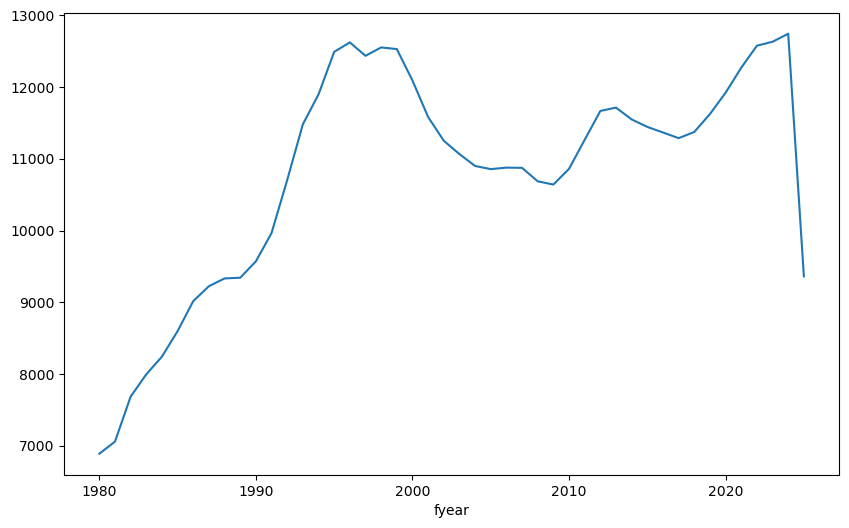

In [23]:
# Number of companies have declined since late 1990s
compa.groupby(['fyear']).gvkey.nunique().plot()

<Axes: xlabel='fyear'>

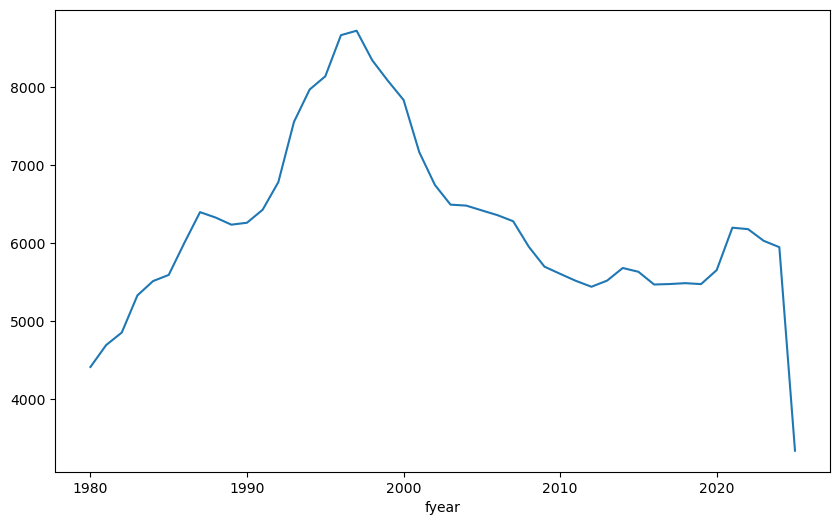

In [24]:
# So does the number of traded stocks
df.groupby(['fyear']).permco.nunique().plot()

* Why do we see a decline in the number of publicly listed stocks?
* Take a look at [Doidge, Karolyi, Stulz (2017)](https://www.sciencedirect.com/science/article/pii/S0304405X1630232X)

## Special Cases

In [25]:
# Should we have duplicated entries for (permco, datadate)?
print(df.duplicated(subset=['permco', 'datadate']).sum())

37313


In [26]:
df.groupby(['permno','datadate']).gvkey.nunique().max()

1

### Many PERMCOs for One GVKEY

In [27]:
df.groupby('gvkey').permco.nunique().max()

4

In [28]:
df.loc[df.gvkey==df.groupby('gvkey').permco.nunique().idxmax(), ['datadate', 'permno', 'permco','gvkey', 'conm', 'at']]

,datadate,permno,permco,gvkey,conm,at
326995,1995-12-31,81875,4388,032280,STARZ,2517.636
326996,1995-12-31,82187,4388,032280,STARZ,2517.636
327005,1996-12-31,81875,4388,032280,STARZ,3058.952
327006,1996-12-31,82187,4388,032280,STARZ,3058.952
327015,1997-12-31,81875,4388,032280,STARZ,5038.561
327016,1997-12-31,82187,4388,032280,STARZ,5038.561
327025,1998-12-31,81875,4388,032280,STARZ,20348.000
327026,1998-12-31,82187,4388,032280,STARZ,20348.000
327037,1999-12-31,86746,20103,032280,STARZ,58684.000
327038,1999-12-31,86747,20103,032280,STARZ,58684.000


### Many GVKEYs for one PERMCO

In [29]:
df[df['at'].notnull()].groupby('permco').gvkey.nunique().max()

5

In [30]:
pp = df[df['at'].notnull()].groupby('permco').gvkey.nunique().idxmax()
df.loc[df.permco==pp, ['datadate', 'permno', 'permco','gvkey', 'conm', 'at']].sort_values(['datadate'])

,datadate,permno,permco,gvkey,conm,at
405317,1994-12-31,81154,8243,118653,GENZYME TISSUE REPAIR,NaN
405318,1995-12-31,81154,8243,118653,GENZYME TISSUE REPAIR,NaN
171199,1996-12-31,10324,8243,012233,GENZYME CORP,1229.519
405319,1996-12-31,81154,8243,118653,GENZYME TISSUE REPAIR,42.593
171200,1997-12-31,10324,8243,012233,GENZYME CORP,1203.056
405320,1997-12-31,81154,8243,118653,GENZYME TISSUE REPAIR,56.818
404291,1998-12-31,86426,8243,117298,GENZYME MOLECULAR ONCOLOGY,35.952
405321,1998-12-31,81154,8243,118653,GENZYME TISSUE REPAIR,18.954
171201,1998-12-31,10324,8243,012233,GENZYME CORP,1646.307
405322,1999-12-31,81154,8243,118653,GENZYME TISSUE REPAIR,19.648


### Many GVKEYs for one PERMCO for the Same Date

In [31]:
df[df['at'].notnull()].groupby(['permco','datadate']).gvkey.nunique().max()

4

In [32]:
pp = df[df['at'].notnull()].groupby(['permco','datadate']).gvkey.nunique().idxmax()
pp

(8243, Timestamp('1999-12-31 00:00:00'))

In [33]:
df.loc[df.permco==8243, ['datadate', 'permno', 'permco','gvkey', 'conm', 'at']].sort_values(['datadate'])

,datadate,permno,permco,gvkey,conm,at
405317,1994-12-31,81154,8243,118653,GENZYME TISSUE REPAIR,NaN
405318,1995-12-31,81154,8243,118653,GENZYME TISSUE REPAIR,NaN
171199,1996-12-31,10324,8243,012233,GENZYME CORP,1229.519
405319,1996-12-31,81154,8243,118653,GENZYME TISSUE REPAIR,42.593
171200,1997-12-31,10324,8243,012233,GENZYME CORP,1203.056
405320,1997-12-31,81154,8243,118653,GENZYME TISSUE REPAIR,56.818
404291,1998-12-31,86426,8243,117298,GENZYME MOLECULAR ONCOLOGY,35.952
405321,1998-12-31,81154,8243,118653,GENZYME TISSUE REPAIR,18.954
171201,1998-12-31,10324,8243,012233,GENZYME CORP,1646.307
405322,1999-12-31,81154,8243,118653,GENZYME TISSUE REPAIR,19.648


In [34]:
df.loc[df.permco==54311, ['datadate', 'permno', 'permco','gvkey', 'conm', 'at']].sort_values(['datadate'])

,datadate,permno,permco,gvkey,conm,at
228546,2013-12-31,13757,54311,017010,LIBERTY MEDIA SIRIUSXM GROUP,34542.0
228547,2013-12-31,13758,54311,017010,LIBERTY MEDIA SIRIUSXM GROUP,34542.0
228554,2014-12-31,13757,54311,017010,LIBERTY MEDIA SIRIUSXM GROUP,31207.0
228555,2014-12-31,13758,54311,017010,LIBERTY MEDIA SIRIUSXM GROUP,31207.0
228556,2014-12-31,14811,54311,017010,LIBERTY MEDIA SIRIUSXM GROUP,31207.0
228562,2015-12-31,13757,54311,017010,LIBERTY MEDIA SIRIUSXM GROUP,29798.0
228563,2015-12-31,13758,54311,017010,LIBERTY MEDIA SIRIUSXM GROUP,29798.0
228564,2015-12-31,14811,54311,017010,LIBERTY MEDIA SIRIUSXM GROUP,29798.0
289155,2016-12-31,14811,54311,027187,LIBERTY MEDIA FORMULA ONE,2995.0
289153,2016-12-31,13757,54311,027187,LIBERTY MEDIA FORMULA ONE,2995.0


## Merge

In [35]:
crspm.columns

Index(['mthcaldt', 'permno', 'mthprc', 'mthprcflg', 'mthprcdt', 'mthdtflg',
       'mthret', 'mthretx', 'mthdelflg', 'mthvol', 'mthshrout', 'mthcumfacpr',
       'mthcumfacshr', 'secinfostartdt', 'secinfoenddt', 'securitybegdt',
       'securityenddt', 'permco', 'cusip', 'hdrcusip', 'ticker', 'securitynm',
       'issuernm', 'primaryexch', 'conditionaltype', 'tradingstatusflg',
       'shareclass', 'sharetype', 'securitytype', 'securitysubtype',
       'usincflg', 'issuertype', 'siccd', 'naics', 'me', 'mesum', 'prc_adj',
       'shrout_adj', 'vol_adj', 'melag_nt', 'melag', 'rankyear', 'mdate',
       'rf'],
      dtype='object')

In [36]:
df.columns

Index(['gvkey', 'datadate', 'conm', 'tic', 'cusip', 'fyear', 'fyr', 'at',
       'capx', 'ceq', 'cogs', 'csho', 'dlc', 'dlcch', 'dltt', 'dp', 'ib',
       'itcb', 'lt', 'mib', 'naicsh', 'ni', 'prstkcc', 'pstk', 'pstkl',
       'pstkrv', 're', 'revt', 'sale', 'seq', 'sich', 'txdb', 'txdi', 'txditc',
       'wcapch', 'xint', 'xlr', 'xrd', 'xsga', 'se', 'ps', 'dt', 'be', 'cost',
       'op', 'opbe', 'at_lag', 'inv', 'fdiff', 'inv_capx', 'permno', 'permco',
       'linktype', 'linkdt', 'linkenddt'],
      dtype='object')

In [37]:
df['rankyear'] = df['datadate'].dt.year + 1
fdata = pd.merge(crspm,
                 df,
                 on = ['permno','rankyear' ],
                how='left')
fdata

,mthcaldt,permno,mthprc,mthprcflg,mthprcdt,mthdtflg,mthret,mthretx,mthdelflg,mthvol,...,op,opbe,at_lag,inv,fdiff,inv_capx,permco_y,linktype,linkdt,linkenddt
0,1986-01-31,10000,4.375000,BA,1986-01-31,PE,0.707317,0.707317,N,1.770820e+05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT
1,1986-02-28,10000,3.250000,BA,1986-02-28,PE,-0.257143,-0.257143,N,8.280000e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT
2,1986-03-31,10000,4.437500,BA,1986-03-31,PE,0.365385,0.365385,N,1.078010e+05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT
3,1986-04-30,10000,4.000000,BA,1986-04-30,PE,-0.098592,-0.098592,N,9.570000e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT
4,1986-05-30,10000,3.109375,BA,1986-05-30,PE,-0.222656,-0.222656,N,1.073620e+05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4128176,2025-08-29,93436,333.870000,TR,2025-08-29,PE,0.083044,0.083044,N,1.598393e+09,...,12778.0,0.17525,106618.0,0.144929,1.0,0.10638,53453.0,LC,2010-06-29,NaT
4128177,2025-09-30,93436,444.720000,TR,2025-09-30,PE,0.332015,0.332015,N,1.966931e+09,...,12778.0,0.17525,106618.0,0.144929,1.0,0.10638,53453.0,LC,2010-06-29,NaT
4128178,2025-10-31,93436,456.560000,TR,2025-10-31,PE,0.026624,0.026624,N,2.024342e+09,...,12778.0,0.17525,106618.0,0.144929,1.0,0.10638,53453.0,LC,2010-06-29,NaT
4128179,2025-11-28,93436,430.170000,TR,2025-11-28,PE,-0.057802,-0.057802,N,1.609832e+09,...,12778.0,0.17525,106618.0,0.144929,1.0,0.10638,53453.0,LC,2010-06-29,NaT


## For next class

**(FI)nance (RE)search Python Tools: fire_pytools**

* To make our lives easier, we will use a version of the fire_pytools package.
    - The original package was written by our alumni, Lira Mota [(see here)](https://bitbucket.org/liramota/fire_pytools/src).
    - Download the updated version of the package [here](https://github.com/kburr97/fire_pytools).
* This is a collection of useful functions in finance research.
    - Direct download of CRSP and Compustat from WRDS server
    - Direct download of Ken French data library
    - Portfolio sorts tools
    - Replicate Fama and French factors